# Day 35 (1/3) — Ridge Regression: Why We Need It

### The story so far
For six days you have fit lines and curves with **Linear Regression**. It works, until a model fits the training data
*so well* that it fails on new data. Today you get the tool that fixes this: **regularisation**.

### In this notebook
1. 😱 **See the problem**: overfitting, in one picture
2. 💡 **The one-line fix**: add a penalty for large weights
3. 📉 **Ridge on a simple line**: watch the slope shrink
4. 🌊 **Ridge on a wiggly curve**: watch it calm down
5. 🏥 **Real data**: diabetes progression, and how to pick `alpha`

> 📖 Theory: [`theory.md`](theory.md) · 🎨 Cells marked *Visualization only* are collapsed: you only need their plots.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': 0.3,
                     'axes.spines.top': False, 'axes.spines.right': False})

---
## 1. 😱 The problem: a model that memorises

40 noisy points from a simple U-shaped curve. We fit two polynomial models:
- **Degree 2**: the right amount of flexibility
- **Degree 15**: far too flexible

In [2]:
rng = np.random.default_rng(42)
x = rng.uniform(-2, 3, 40)
y = 0.7 * x**2 - 2 * x + 3 + rng.normal(0, 1, 40)

x_train, x_test, y_train, y_test = train_test_split(x.reshape(-1, 1), y, test_size=0.3, random_state=0)

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

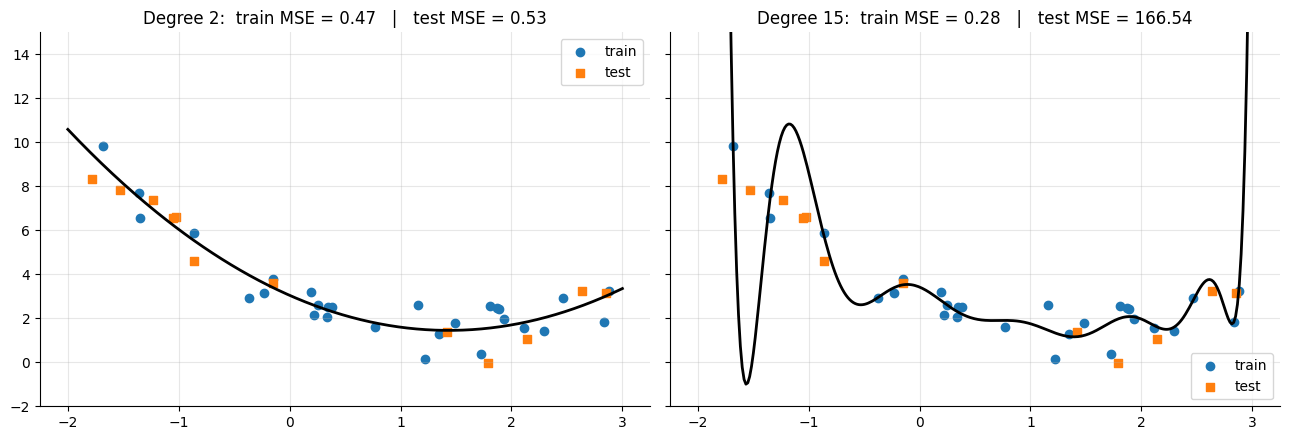

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

grid = np.linspace(-2, 3, 300).reshape(-1, 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, degree in zip(axes, [2, 15]):
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), LinearRegression())
    model.fit(x_train, y_train)
    train_mse = mean_squared_error(y_train, model.predict(x_train))
    test_mse = mean_squared_error(y_test, model.predict(x_test))
    ax.scatter(x_train, y_train, label='train', color='tab:blue')
    ax.scatter(x_test, y_test, label='test', color='tab:orange', marker='s')
    ax.plot(grid, model.predict(grid), color='black', linewidth=2)
    ax.set_ylim(-2, 15)
    ax.set_title(f'Degree {degree}:  train MSE = {train_mse:.2f}   |   test MSE = {test_mse:.2f}')
    ax.legend()
plt.tight_layout()
plt.show()

**What happened?** The degree-15 model bends itself to pass near every *training* point, so its training error is lower.
But it learned the **noise**, not the pattern, and its **test error is much worse**. This is **overfitting** (high variance).

An overfit model has a tell-tale sign: **huge coefficients**. The curve needs large positive and negative weights that
cancel out to make those sharp wiggles.

---
## 2. 💡 The fix: penalise large weights

Linear regression minimises only the error. **Ridge** adds a second term:

$$
\text{Loss}_{\text{Ridge}} \;=\; \underbrace{\sum_{i}(y_i - \hat y_i)^2}_{\text{fit the data}} \;+\; \underbrace{\alpha \sum_{j} w_j^2}_{\text{keep weights small}}
$$

Think of it as a **tug-of-war**:
- The first term wants the model to fit the training data perfectly.
- The second term charges a fee for every large weight.
- **α (alpha)** sets how expensive that fee is.

| α | Effect |
|---|---|
| 0 | No penalty: plain Linear Regression |
| small | Weights shrink a little: less overfitting |
| huge | Weights forced near 0: the model predicts almost a flat line (underfitting) |

> The intercept $b$ is **not** penalised; it only shifts the line up or down.

---
## 3. 📉 Ridge on a simple straight line

One feature, so the model is $\hat y = m x + b$. Watch the slope $m$ as α grows.

> ✍️ **Core code: learn this.** This is how you use Ridge: the same `fit` / `predict` API as `LinearRegression`, plus `alpha`.

In [4]:
from sklearn.datasets import make_regression

X1, y1 = make_regression(n_samples=100, n_features=1, noise=20, random_state=13)

for alpha in [0, 10, 100, 1000]:
    model = Ridge(alpha=alpha).fit(X1, y1)
    print(f"alpha = {alpha:<5}  slope m = {model.coef_[0]:6.2f}   intercept b = {model.intercept_:6.2f}")

alpha = 0      slope m =  27.83   intercept b =  -2.29
alpha = 10     slope m =  24.95   intercept b =  -2.13
alpha = 100    slope m =  12.93   intercept b =  -1.42
alpha = 1000   slope m =   2.22   intercept b =  -0.80


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

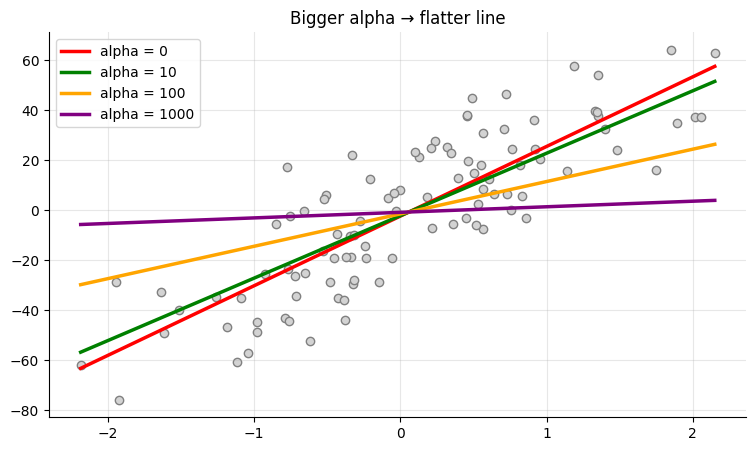

In [5]:
xs = np.linspace(X1.min(), X1.max(), 2).reshape(-1, 1)
plt.figure(figsize=(9, 5))
plt.scatter(X1, y1, color='lightgray', edgecolor='gray')
for alpha, c in zip([0, 10, 100, 1000], ['red', 'green', 'orange', 'purple']):
    plt.plot(xs, Ridge(alpha=alpha).fit(X1, y1).predict(xs), color=c, linewidth=2.5, label=f'alpha = {alpha}')
plt.legend()
plt.title('Bigger alpha → flatter line')
plt.show()

The slope drops from about 28 toward 0 as α grows. The line is **pulled toward flat**, but never fully flat:
Ridge shrinks weights, it does **not** remove them.

---
## 4. 🌊 Ridge calms down a wiggly model

Same degree-15 polynomial as in Section 1, now with Ridge instead of plain Linear Regression.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

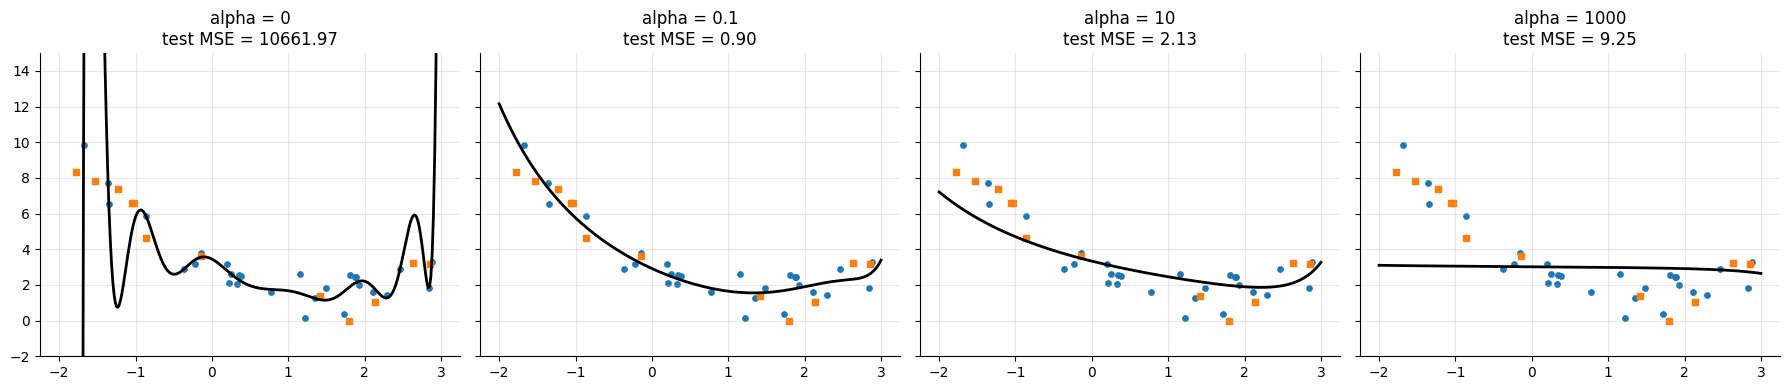

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, alpha in zip(axes, [0, 0.1, 10, 1000]):
    model = make_pipeline(PolynomialFeatures(15, include_bias=False), StandardScaler(), Ridge(alpha=alpha))
    model.fit(x_train, y_train)
    test_mse = mean_squared_error(y_test, model.predict(x_test))
    ax.scatter(x_train, y_train, s=15, color='tab:blue')
    ax.scatter(x_test, y_test, s=15, color='tab:orange', marker='s')
    ax.plot(grid, model.predict(grid), color='black', linewidth=2)
    ax.set_ylim(-2, 15)
    ax.set_title(f'alpha = {alpha}\ntest MSE = {test_mse:.2f}')
plt.tight_layout()
plt.show()

Left to right: **overfit → just right → underfit**. Same model, same features; only α changed.
Choosing α is choosing where you stand on this spectrum.

---
## 5. 🏥 Real data: predicting diabetes progression

In [7]:
from sklearn.datasets import load_diabetes

X, y = load_diabetes(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
features = X.columns
print(X.shape)
X.head()

(442, 10)


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


**Diabetes dataset:** 442 patients, 10 features (age, sex, BMI, blood pressure, six blood measurements `s1`–`s6`),
target = disease progression after one year. The features are **already standardised** by scikit-learn. With your own data,
always scale first, because the penalty treats all coefficients equally (see `theory.md`).

> ✍️ **Core code: learn this.** Compare Linear Regression and Ridge on the same split.

In [8]:
def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    return {'model': name,
            'test R²': round(r2_score(y_test, pred), 3),
            'test RMSE': round(np.sqrt(mean_squared_error(y_test, pred)), 2),
            'largest |weight|': round(np.abs(model.coef_).max(), 1)}

pd.DataFrame([
    evaluate('LinearRegression', LinearRegression()),
    evaluate('Ridge (alpha=0.1)', Ridge(alpha=0.1)),
    evaluate('Ridge (alpha=100000)', Ridge(alpha=100000)),
])

,model,test R²,test RMSE,largest |weight|
0,LinearRegression,0.440,55.63,895.6
1,Ridge (alpha=0.1),0.452,55.03,485.5
2,Ridge (alpha=100000),-0.012,74.79,0.0


- **α = 0.1** slightly *improves* the test score and makes the weights smaller (more stable).
- **α = 100000** crushes every weight to ≈ 0. The model predicts roughly the average for everyone, so R² ≈ 0. **Too much regularisation underfits.**

### How do we find the best α?
Try many values and let **cross-validation** pick: `RidgeCV` does exactly that.

> ✍️ **Core code: learn this.** `RidgeCV` = Ridge + automatic α search.

In [9]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=np.logspace(-4, 3, 50))   # 50 values from 0.0001 to 1000
ridge_cv.fit(X_train, y_train)

print("Best alpha :", round(ridge_cv.alpha_, 4))
print("Test R²    :", round(r2_score(y_test, ridge_cv.predict(X_test)), 3))

Best alpha : 0.0027
Test R²    : 0.442


`RidgeCV` chose α using **only the training data**, so its test score need not beat every α we tried by hand.
That is correct practice: picking α by looking at the test set would give an over-optimistic score.

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

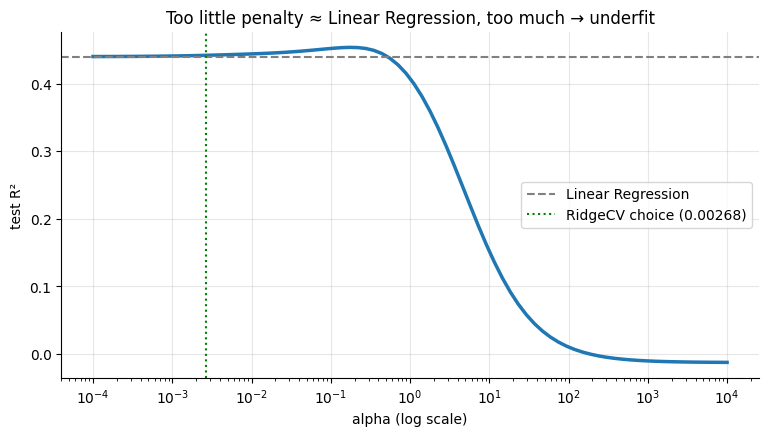

In [10]:
alphas = np.logspace(-4, 4, 80)
scores = [r2_score(y_test, Ridge(alpha=a).fit(X_train, y_train).predict(X_test)) for a in alphas]

plt.figure(figsize=(9, 4.5))
plt.plot(alphas, scores, linewidth=2.5)
plt.axhline(r2_score(y_test, LinearRegression().fit(X_train, y_train).predict(X_test)),
            color='gray', linestyle='--', label='Linear Regression')
plt.axvline(ridge_cv.alpha_, color='green', linestyle=':', label=f'RidgeCV choice ({ridge_cv.alpha_:.3g})')
plt.xscale('log')
plt.xlabel('alpha (log scale)')
plt.ylabel('test R²')
plt.title('Too little penalty ≈ Linear Regression, too much → underfit')
plt.legend()
plt.show()

---
## 🧠 Quick check

<details><summary>1. What does Ridge add to the Linear Regression loss?</summary>

$\alpha \sum w_j^2$, a penalty on the squared size of the weights.
</details>

<details><summary>2. What happens when α = 0? When α is enormous?</summary>

α = 0 gives plain Linear Regression. Enormous α pushes all weights to ≈ 0, so the model predicts ≈ the mean (underfitting).
</details>

<details><summary>3. Does Ridge ever set a weight to exactly 0?</summary>

No, it only shrinks weights toward 0. Removing features is Lasso's job (Day 36).
</details>

<details><summary>4. How should you choose α?</summary>

Cross-validation, e.g. `RidgeCV(alphas=...)`, never the test set.
</details>

➡️ **Next:** `02-ridge-key-understandings.ipynb`: four pictures that explain *how* Ridge behaves.